# Tugas Besar 1 Pembelajaran Mesin

13523003 Dave Daniell Yanni

13523036 Yonatan Edward Njoto

## 1. Import Library

Mengimpor dependensi eksternal (pandas, numpy, matplotlib, scikit-learn) dan modul internal (`NeuralNetwork` dari package `core`).

In [1]:
# external lib imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier


SEED_VALUE = 36
np.random.seed(SEED_VALUE)


In [2]:
# internal lib import
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from core import NeuralNetwork
from core import AutogradNeuralNetwork

ChosenNetwork=AutogradNeuralNetwork


## 2. Memuat & Menjelajahi Data

Dataset `datasetml_2026.csv` berisi data penempatan kerja mahasiswa dengan fitur numerik (CGPA, skor aptitude, dll.) dan kategorikal (tier kampus, spesialisasi, dll.). Target variabel adalah `placement_status` (Placed / Not Placed).

In [3]:
# Load the dataset
df = pd.read_csv("../data/datasetml_2026.csv")

### Eksplorasi Awal (EDA)

Melihat beberapa baris pertama dan tipe data setiap kolom untuk memahami struktur dataset sebelum dilakukan *preprocessing*.

In [4]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [5]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

### 3. Preprocessing Data

Langkah-langkah preprocessing:
1. **Pisahkan fitur (X) dan target (y)** — target `placement_status` diubah ke biner (1 = Placed, 0 = Not Placed).
2. **Scaling numerik** — `StandardScaler` menormalisasi fitur numerik agar berpusat di 0 dengan standar deviasi 1.
3. **One-Hot Encoding** — fitur kategorikal dikonversi menjadi representasi biner (drop-first untuk menghindari *multicollinearity*).
4. **Train/Validation Split** — 80% training, 20% validasi (`random_state=42` untuk reproduktifitas).

In [6]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status'].values
y = np.where(y == "Placed", 1, 0) 

# Preprocess Categorical and Numerical Columns
categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
numerical_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=SEED_VALUE)

# Reshape y for the Neural Network to (batch_size, 1)
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (8000, 23)
y_train shape: (8000, 1)


## 4. Eksperimen

### Eksperimen 1 — Depth & Width




EXPERIMENT 1: DEPTH AND WIDTH VARIATIONS

--- Running Width Variations (Fixed 2 Hidden Layers) ---
[Width 16] F1 Score: 0.80062 | Accuracy: 0.74250
[Width 32] F1 Score: 0.80308 | Accuracy: 0.74450
[Width 64] F1 Score: 0.80417 | Accuracy: 0.74650

--- Running Depth Variations (Fixed 32 Neurons Width) ---
[Depth 1 (1 Hidden)] F1 Score: 0.80385 | Accuracy: 0.74500
[Depth 2 (2 Hidden)] F1 Score: 0.80308 | Accuracy: 0.74450
[Depth 3 (3 Hidden)] F1 Score: 0.80247 | Accuracy: 0.74450


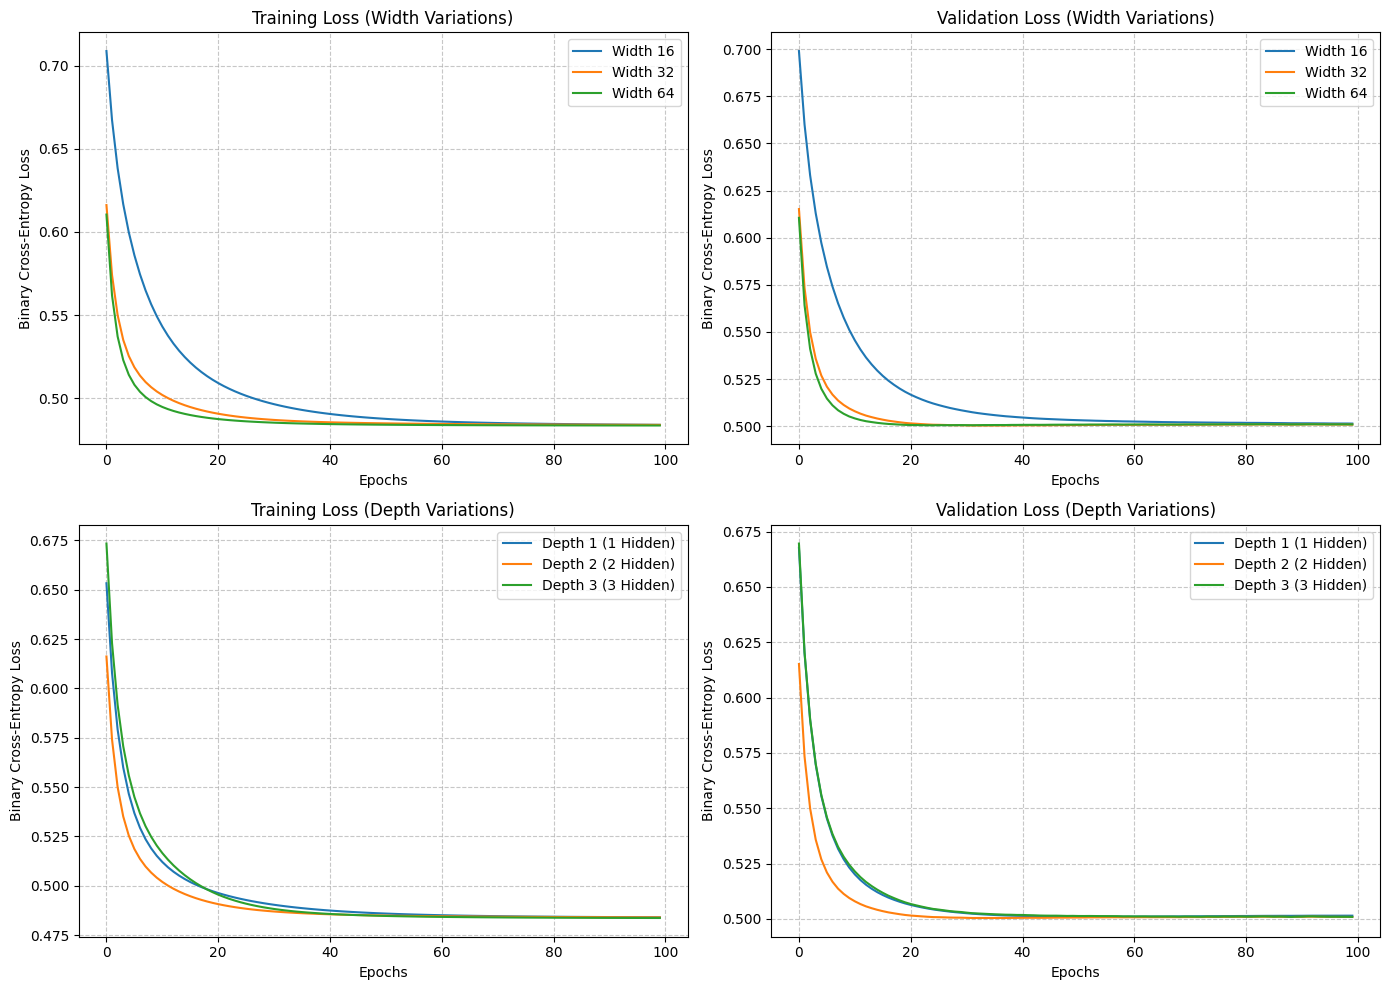

In [7]:
# =====================================================================
# --- EXPERIMENT 1: EFFECT OF DEPTH AND WIDTH ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 1: DEPTH AND WIDTH VARIATIONS")
print("="*50)

INPUT_DIM = X_train.shape[1]
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001

# Define variations
# 1. Width variations (Fixed depth: 2 hidden layers)
width_configs = {
    "Width 16": [INPUT_DIM, 16, 16, 1],
    "Width 32": [INPUT_DIM, 32, 32, 1],
    "Width 64": [INPUT_DIM, 64, 64, 1]
}

# 2. Depth variations (Fixed width: 32 neurons per hidden layer)
depth_configs = {
    "Depth 1 (1 Hidden)": [INPUT_DIM, 32, 1],
    "Depth 2 (2 Hidden)": [INPUT_DIM, 32, 32, 1],
    "Depth 3 (3 Hidden)": [INPUT_DIM, 32, 32, 32, 1]
}

def train_and_evaluate(name, layer_sizes):
    # Determine activations: 'linear' for hidden, 'sigmoid' for output
    acts = ["linear"] * (len(layer_sizes) - 2) + ["sigmoid"]

    model = ChosenNetwork(layer_sizes=layer_sizes, activations=acts, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)

    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    acc = accuracy_score(y_val, y_pred)

    print(f"[{name}] F1 Score: {f1:.5f} | Accuracy: {acc:.5f}")
    return history

# Run Width Experiments
print("\n--- Running Width Variations (Fixed 2 Hidden Layers) ---")
width_histories = {}
for name, sizes in width_configs.items():
    width_histories[name] = train_and_evaluate(name, sizes)

# Run Depth Experiments
print("\n--- Running Depth Variations (Fixed 32 Neurons Width) ---")
depth_histories = {}
for name, sizes in depth_configs.items():
    depth_histories[name] = train_and_evaluate(name, sizes)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Width Loss
for name, hist in width_histories.items():
    axes[0, 0].plot(hist['train_loss'], label=f"{name}")
    axes[0, 1].plot(hist['val_loss'], label=f"{name}")
axes[0, 0].set_title("Training Loss (Width Variations)")
axes[0, 1].set_title("Validation Loss (Width Variations)")

# Plot Depth Loss
for name, hist in depth_histories.items():
    axes[1, 0].plot(hist['train_loss'], label=f"{name}")
    axes[1, 1].plot(hist['val_loss'], label=f"{name}")
axes[1, 0].set_title("Training Loss (Depth Variations)")
axes[1, 1].set_title("Validation Loss (Depth Variations)")

for ax in axes.flatten():
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Binary Cross-Entropy Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Analisis - Eksperimen 1

#### A. Hasil Prediksi Akhir

**Variasi lebar (width), depth tetap 2 hidden layer:**

| Konfigurasi | F1 Score | Accuracy |
|:-----------:|:--------:|:--------:|
| Width 16 | 0.80062 | 0.74250 |
| Width 32 | 0.80308 | 0.74450 |
| Width 64 | **0.80417** | **0.74650** |

**Variasi kedalaman (depth), width tetap 32:**

| Konfigurasi | F1 Score | Accuracy |
|:-----------:|:--------:|:--------:|
| **Depth 1 (1 Hidden)** | **0.80385** | **0.74500** |
| Depth 2 (2 Hidden) | 0.80308 | 0.74450 |
| Depth 3 (3 Hidden) | 0.80247 | 0.74450 |

#### B. Interpretasi Kurva Loss

- Semua konfigurasi konvergen dan gap train/validation relatif kecil.
- Pada variasi width, model lebih lebar (Width 64) memberi performa validasi terbaik.
- Pada variasi depth, penambahan hidden layer tidak memberi peningkatan berarti pada setup ini.

**Kesimpulan Eksperimen 1:** hasil terbaik pada run ini adalah **Width 64** (F1 0.80417) untuk uji width dan **Depth 1** (F1 0.80385) untuk uji depth.

## Eksperimen 2 — Activation Function


EXPERIMENT 2: HIDDEN LAYER 1 ACTIVATION
Base Architecture: [23, 32, 32, 32, 1]
Testing activations on Hidden Layer 1 (Layer index 0)...
[Act: RELU        ] F1 Score: 0.79784
[Act: SIGMOID     ] F1 Score: 0.80386
[Act: TANH        ] F1 Score: 0.80000
[Act: LINEAR      ] F1 Score: 0.80077
[Act: LEAKY_RELU  ] F1 Score: 0.79877
[Act: SWISH       ] F1 Score: 0.80062


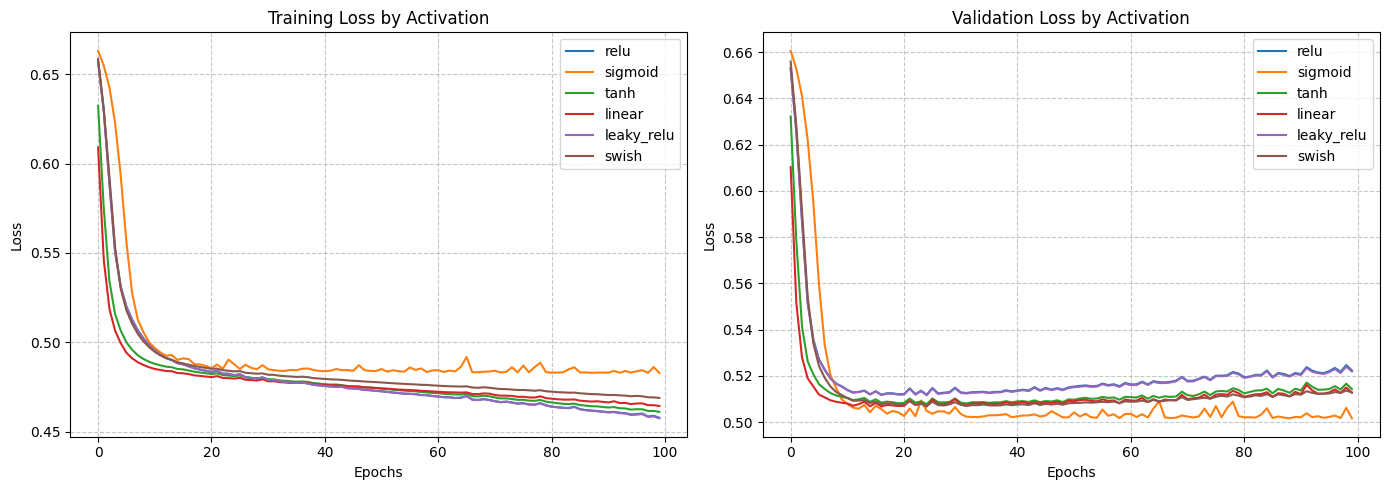


--- Displaying Weight & Gradient Distributions for Layer 0 (The Tested Layer) ---

Distributions for 'relu' activation model:


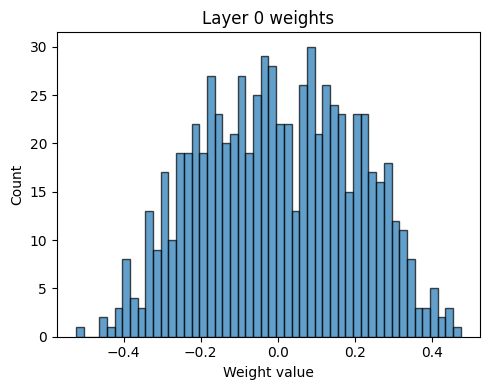

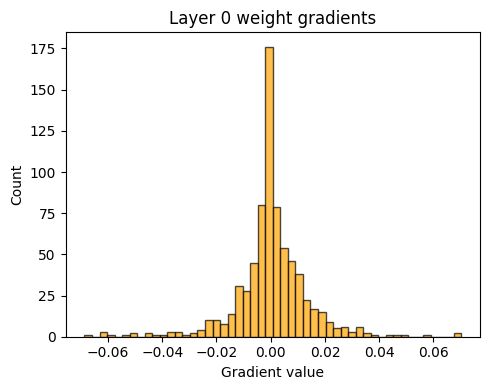


Distributions for 'sigmoid' activation model:


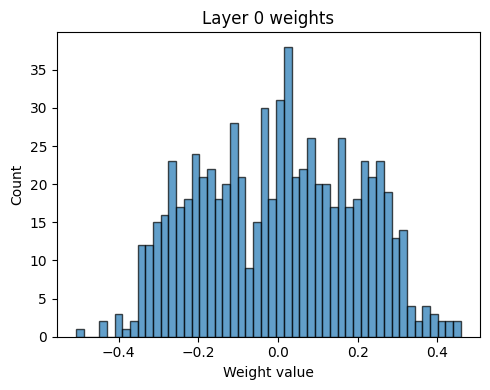

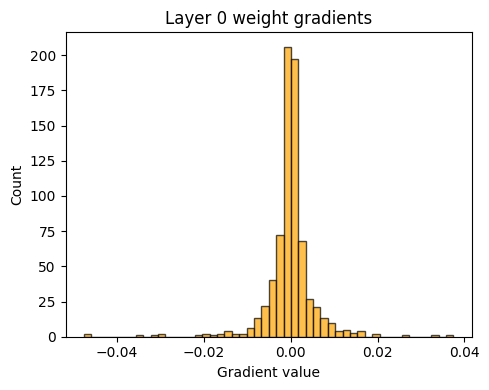


Distributions for 'tanh' activation model:


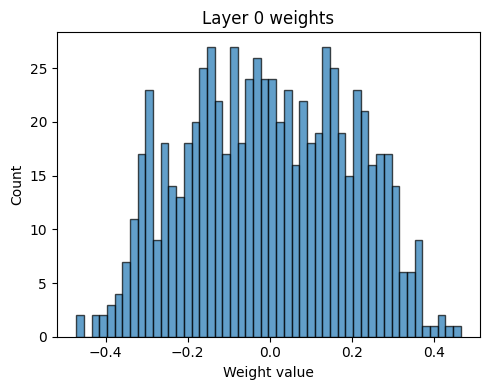

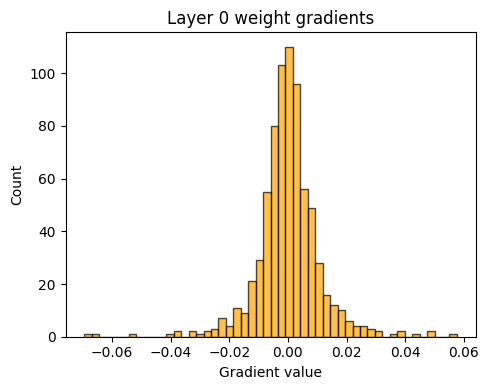


Distributions for 'linear' activation model:


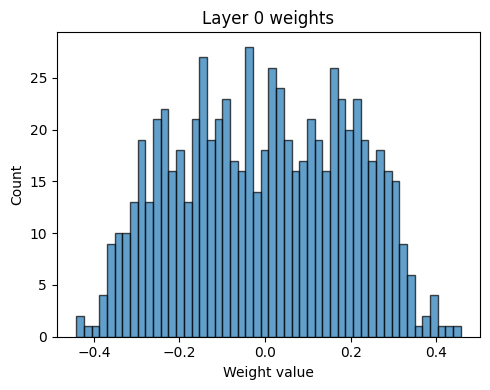

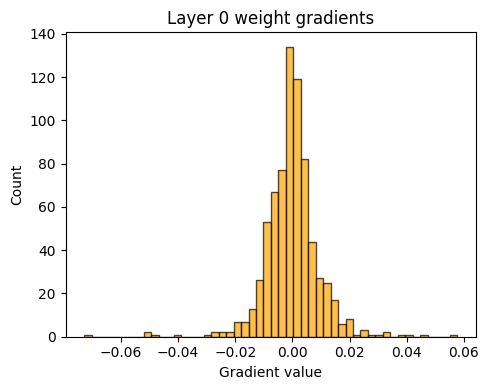


Distributions for 'leaky_relu' activation model:


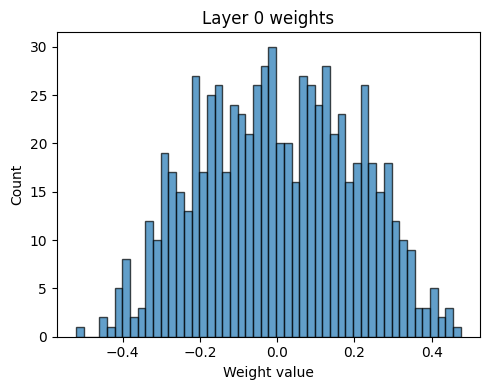

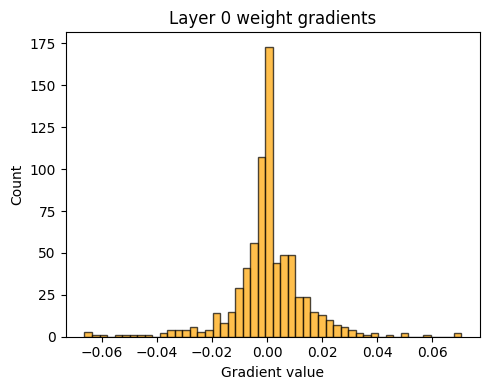


Distributions for 'swish' activation model:


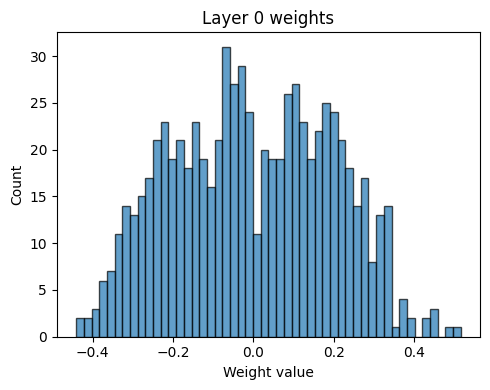

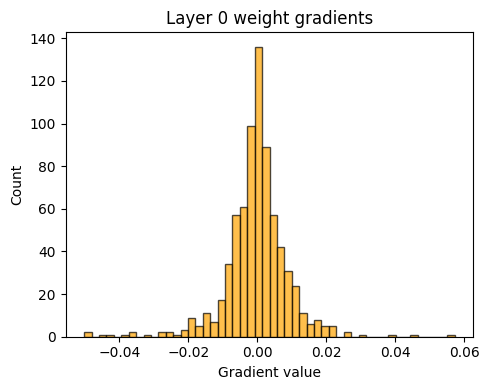

In [8]:
# =====================================================================
# --- EXPERIMENT 2: EFFECT OF ACTIVATION FUNCTIONS ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 2: HIDDEN LAYER 1 ACTIVATION")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 32, 1] # 3 Hidden Layers
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.01

test_activations = ["relu", "sigmoid", "tanh", "linear", "leaky_relu", "swish"]
act_histories = {}
act_models = {}

print("Base Architecture:", BASE_ARCH)
print("Testing activations on Hidden Layer 1 (Layer index 0)...")

for act in test_activations:
    # First hidden uses 'act', second & third hidden uses 'relu', output uses 'sigmoid'
    activations_list = [act, "relu", "relu", "sigmoid"]
    
    model = ChosenNetwork(layer_sizes=BASE_ARCH, activations=activations_list, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), 
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)
    
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')
    
    print(f"[Act: {act.upper():<12}] F1 Score: {f1:.5f}")
    
    act_histories[act] = history
    act_models[act] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for act, hist in act_histories.items():
    axes[0].plot(hist['train_loss'], label=f"{act}")
    axes[1].plot(hist['val_loss'], label=f"{act}")

axes[0].set_title("Training Loss by Activation")
axes[1].set_title("Validation Loss by Activation")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
print("\n--- Displaying Weight & Gradient Distributions for Layer 0 (The Tested Layer) ---")
for act, model in act_models.items():
    print(f"\nDistributions for '{act}' activation model:")
    model.plot_weight_distribution(layers=[0])
    model.plot_gradient_distribution(layers=[0])

### Analisis - Eksperimen 2

#### A. Hasil Prediksi Akhir

**F1 Score per fungsi aktivasi pada hidden layer 1 (arsitektur [23, 32, 32, 32, 1]):**

| Aktivasi | F1 Score |
|:--------:|:--------:|
| **Sigmoid** | **0.80386** |
| Linear | 0.80077 |
| Swish | 0.80062 |
| Tanh | 0.80000 |
| Leaky ReLU | 0.79877 |
| ReLU | 0.79784 |

#### B. Interpretasi Kurva Loss

- ReLU, Leaky ReLU, dan Swish menurun lebih cepat di fase awal training.
- Sigmoid menurun lebih lambat, tetapi menghasilkan F1 akhir tertinggi pada validasi.
- Seluruh konfigurasi berakhir pada rentang val_loss yang berdekatan, sehingga perbedaan performa akhir relatif kecil.

#### C. Interpretasi Bobot dan Gradien

- Sigmoid cenderung memiliki gradien lebih sempit di sekitar nol, konsisten dengan kecenderungan vanishing gradient lokal.
- ReLU-family menunjukkan distribusi gradien lebih tersebar dan stabil.
- Karena hanya layer pertama yang diuji, efek perbedaan aktivasi terhadap performa total tetap terbatas.

**Kesimpulan Eksperimen 2:** **Sigmoid** memberi F1 terbaik (**0.80386**), tetapi margin terhadap aktivasi lain kecil sehingga sensitivitas terhadap pilihan aktivasi tidak besar untuk dataset ini.

## Eksperimen 3 — Learning Rate


EXPERIMENT 3: LEARNING RATE VARIATIONS
[LR: 0.1   ] F1 Score: 0.8031
[LR: 0.01  ] F1 Score: 0.8032
[LR: 0.001 ] F1 Score: 0.8031


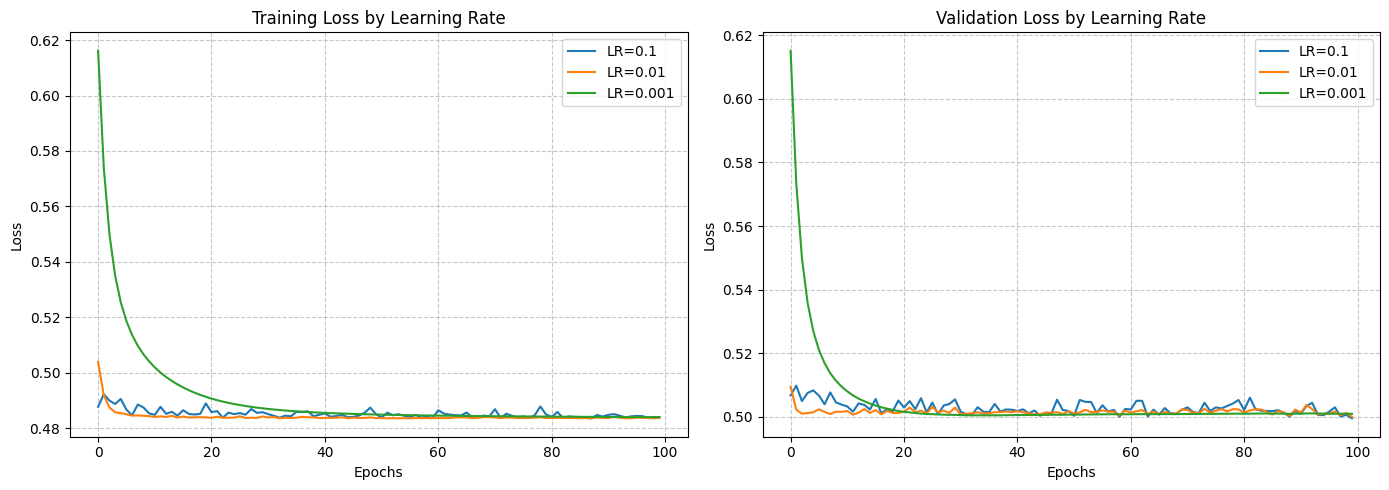


--- Displaying Distributions (Showing Layer 1 for each LR) ---

Distributions for LR=0.1:


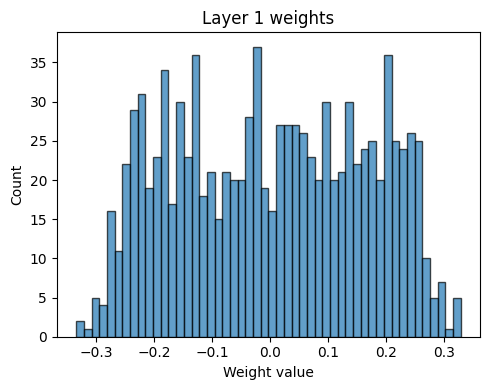

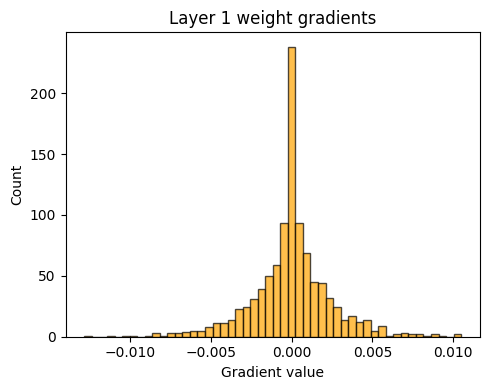


Distributions for LR=0.01:


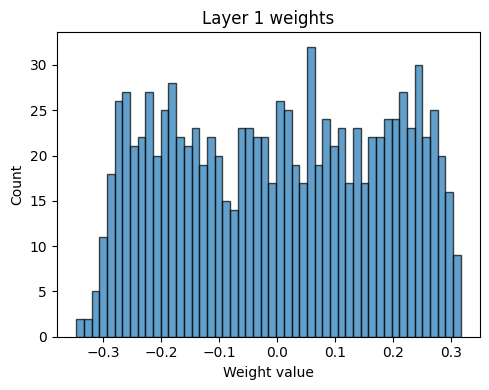

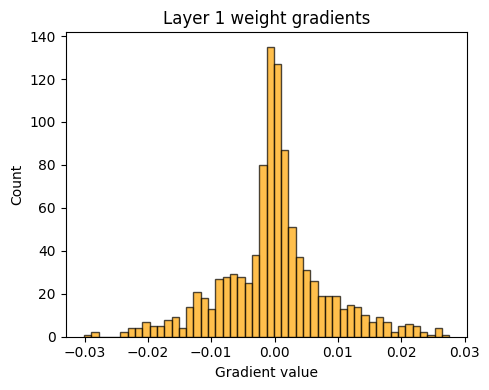


Distributions for LR=0.001:


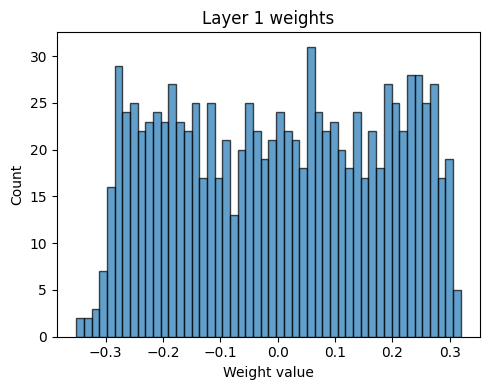

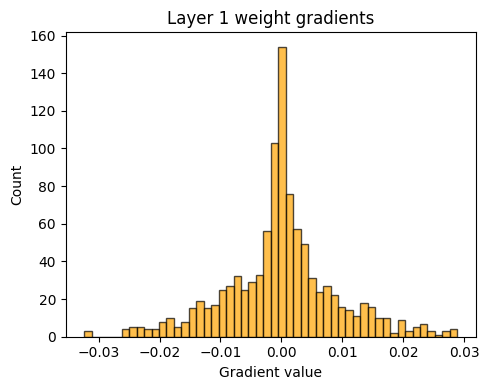

In [9]:
# =====================================================================
# --- EXPERIMENT 3: EFFECT OF LEARNING RATE ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 3: LEARNING RATE VARIATIONS")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["linear", "linear", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32

learning_rates = [0.1, 0.01, 0.001]
lr_histories = {}
lr_models = {}

for lr in learning_rates:
    model = ChosenNetwork(layer_sizes=BASE_ARCH, activations=ACTIVATIONS, loss="bce", seed=SEED_VALUE)
    history = model.fit(X_train, y_train, val_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=lr, verbose=0)

    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')

    print(f"[LR: {lr:<6}] F1 Score: {f1:.4f}")

    lr_histories[lr] = history
    lr_models[lr] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, hist in lr_histories.items():
    axes[0].plot(hist['train_loss'], label=f"LR={lr}")
    axes[1].plot(hist['val_loss'], label=f"LR={lr}")

axes[0].set_title("Training Loss by Learning Rate")
axes[1].set_title("Validation Loss by Learning Rate")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
print("\n--- Displaying Distributions (Showing Layer 1 for each LR) ---")
for lr, model in lr_models.items():
    print(f"\nDistributions for LR={lr}:")
    model.plot_weight_distribution(layers=[1])
    model.plot_gradient_distribution(layers=[1])

### Analisis - Eksperimen 3

#### A. Hasil Prediksi Akhir

**F1 Score per learning rate (arsitektur [INPUT, 32, 32, 1], aktivasi linear-linear-sigmoid):**

| Learning Rate | F1 Score |
|:-------------:|:--------:|
| 0.1 | 0.8031 |
| **0.01** | **0.8032** |
| 0.001 | 0.8031 |

#### B. Interpretasi Kurva Loss

- Ketiga learning rate menghasilkan F1 akhir yang sangat berdekatan.
- **LR = 0.1** turun cepat di awal, tetapi kurva loss lebih berisik dibanding dua nilai LR lain.
- **LR = 0.01** dan **LR = 0.001** lebih stabil; pada run ini **LR = 0.01** unggul tipis pada F1 validasi akhir.

#### C. Implikasi ke Update Bobot

Rumus update bobot:

$$W_{t+1} = W_t - \eta \nabla_W \mathcal{L}$$

- Nilai $\eta$ besar mempercepat langkah, tetapi berpotensi membuat update lebih tidak stabil.
- Nilai $\eta$ kecil cenderung lebih halus, namun bisa memperlambat laju konvergensi awal.

**Kesimpulan Eksperimen 3:** untuk run ini, **LR = 0.01** menjadi pilihan terbaik (F1 = 0.8032), dengan selisih yang sangat kecil terhadap LR lain.

## Eksperimen 3B - Optimizer (SGD vs Adam)

Membandingkan **Gradient Descent standar (SGD)** dan **Adam** dengan aktivasi hidden **linear-linear** (output sigmoid), serta membandingkan dua kandidat learning rate: **0.001** dan **0.0001**.


EXPERIMENT 3B: OPTIMIZER + LR COMPARISON (SGD vs ADAM)
[SGD | LR=0.001    ] F1: 0.8031 | best val_loss: 0.5004 (epoch 32)
[ADAM | LR=0.001   ] F1: 0.8032 | best val_loss: 0.4996 (epoch 31)
[SGD | LR=0.0001   ] F1: 0.7991 | best val_loss: 0.5094 (epoch 100)
[ADAM | LR=0.0001  ] F1: 0.8034 | best val_loss: 0.5002 (epoch 8)

--- Convergence Speed Summary ---
Target val_loss threshold: <= 0.5096
SGD | LR=0.001     | best val_loss: 0.5004 (epoch 32) | epoch to target: 10
ADAM | LR=0.001    | best val_loss: 0.4996 (epoch 31) | epoch to target: 1
SGD | LR=0.0001    | best val_loss: 0.5094 (epoch 100) | epoch to target: 99
ADAM | LR=0.0001   | best val_loss: 0.5002 (epoch 8) | epoch to target: 3

--- Ranking by Final F1 (Validation) ---
1. ADAM | LR=0.0001   | F1=0.8034
2. ADAM | LR=0.001    | F1=0.8032
3. SGD | LR=0.001     | F1=0.8031
4. SGD | LR=0.0001    | F1=0.7991

Best config by F1: ADAM | LR=0.0001 (F1=0.8034, best val_loss=0.5002)


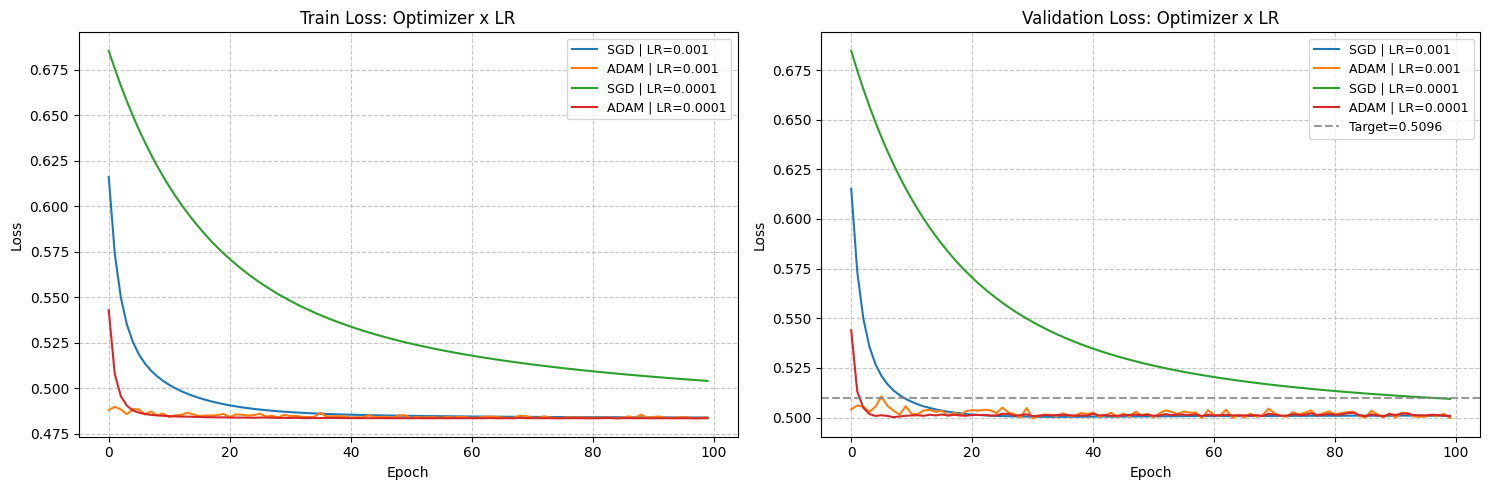

In [10]:
print("\n" + "=" * 78)
print("EXPERIMENT 3B: OPTIMIZER + LR COMPARISON (SGD vs ADAM)")
print("=" * 78)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["linear", "linear", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32
LR_CANDIDATES = [0.001, 0.0001]
optimizers = ["sgd", "adam"]

cfg_histories = {}
cfg_models = {}
results = []

for lr in LR_CANDIDATES:
    for opt in optimizers:
        label = f"{opt.upper()} | LR={lr:g}"

        model = ChosenNetwork(
            layer_sizes=BASE_ARCH,
            activations=ACTIVATIONS,
            loss="bce",
            seed=SEED_VALUE,
        )

        history = model.fit(
            X_train,
            y_train,
            val_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=lr,
            optimizer=opt,
            verbose=0,
        )

        y_pred_probs = model.predict(X_val)
        y_pred = (y_pred_probs > 0.5).astype(int)
        f1 = f1_score(y_val.ravel(), y_pred.ravel(), average="binary")

        best_loss = float(np.min(history["val_loss"]))
        best_epoch = int(np.argmin(history["val_loss"]) + 1)

        cfg_histories[label] = history
        cfg_models[label] = model

        results.append(
            {
                "label": label,
                "optimizer": opt,
                "lr": lr,
                "f1": float(f1),
                "best_val_loss": best_loss,
                "best_val_epoch": best_epoch,
            }
        )

        print(
            f"[{label:<18}] F1: {f1:.4f} | "
            f"best val_loss: {best_loss:.4f} (epoch {best_epoch})"
        )

# Shared target for convergence-speed comparison.
target_val_loss = min(r["best_val_loss"] for r in results) + 0.01

def first_epoch_reaching_target(hist, target):
    vals = np.asarray(hist["val_loss"], dtype=np.float64)
    idx = np.where(vals <= target)[0]
    return int(idx[0] + 1) if len(idx) > 0 else None

for r in results:
    reached = first_epoch_reaching_target(cfg_histories[r["label"]], target_val_loss)
    r["epoch_to_target"] = reached

print("\n--- Convergence Speed Summary ---")
print(f"Target val_loss threshold: <= {target_val_loss:.4f}")
for r in results:
    reached_txt = str(r["epoch_to_target"]) if r["epoch_to_target"] is not None else "Not reached"
    print(
        f"{r['label']:<18} | best val_loss: {r['best_val_loss']:.4f} "
        f"(epoch {r['best_val_epoch']}) | epoch to target: {reached_txt}"
    )

# Ranking by final F1
ranked_by_f1 = sorted(results, key=lambda x: x["f1"], reverse=True)
print("\n--- Ranking by Final F1 (Validation) ---")
for i, r in enumerate(ranked_by_f1, start=1):
    print(f"{i}. {r['label']:<18} | F1={r['f1']:.4f}")

best_cfg = ranked_by_f1[0]
print(
    f"\nBest config by F1: {best_cfg['label']} "
    f"(F1={best_cfg['f1']:.4f}, best val_loss={best_cfg['best_val_loss']:.4f})"
)

# --- Plot loss curves ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for label, hist in cfg_histories.items():
    axes[0].plot(hist["train_loss"], label=label)
    axes[1].plot(hist["val_loss"], label=label)

axes[1].axhline(
    target_val_loss,
    linestyle="--",
    color="gray",
    alpha=0.8,
    label=f"Target={target_val_loss:.4f}",
)

axes[0].set_title("Train Loss: Optimizer x LR")
axes[1].set_title("Validation Loss: Optimizer x LR")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Analisis - Eksperimen 3B (Optimizer + LR)

#### A. Ringkasan Hasil

Arsitektur yang diuji: `[INPUT, 32, 32, 1]` dengan aktivasi **linear-linear-sigmoid**, `batch_size=32`, `epochs=100`.

| Konfigurasi | F1 Validasi | Best Val Loss | Epoch Best | Epoch ke Target (<= 0.5096) |
|:--|:--:|:--:|:--:|:--:|
| SGD, LR=0.001 | 0.8031 | 0.5004 | 32 | 10 |
| Adam, LR=0.001 | 0.8032 | **0.4996** | 31 | **1** |
| SGD, LR=0.0001 | 0.7991 | 0.5094 | 100 | 99 |
| Adam, LR=0.0001 | **0.8034** | 0.5002 | 8 | 3 |

#### B. Interpretasi Konvergensi

- Pada **LR = 0.001**, Adam konvergen paling cepat (epoch target = 1) dan memiliki best val loss terbaik (0.4996), dengan F1 hampir setara SGD.
- Pada **LR = 0.0001**, SGD menjadi terlalu lambat (best loss baru tercapai di epoch 100), sedangkan Adam tetap cepat dan stabil.
- Secara keseluruhan, Adam lebih robust terhadap penurunan learning rate pada setup aktivasi linear-linear ini.

#### C. Kesimpulan

- Jika fokus utama adalah **F1 akhir**, konfigurasi terbaik pada run ini adalah **Adam + LR=0.0001** (F1 = **0.8034**).
- Jika fokus utama adalah **konvergensi tercepat**, **Adam + LR=0.001** adalah yang tercepat mencapai target loss.
- Jadi, **Adam** lebih direkomendasikan daripada SGD pada aktivasi linear-linear-sigmoid di dataset ini.

## Eksperimen 4 — Initialization



EXPERIMENT 4: WEIGHT INITIALIZATION
[Init: zero    ] F1 Score: 0.76657
[Init: uniform ] F1 Score: 0.80980
[Init: normal  ] F1 Score: 0.79862
[Init: xavier  ] F1 Score: 0.80308
[Init: he      ] F1 Score: 0.80631


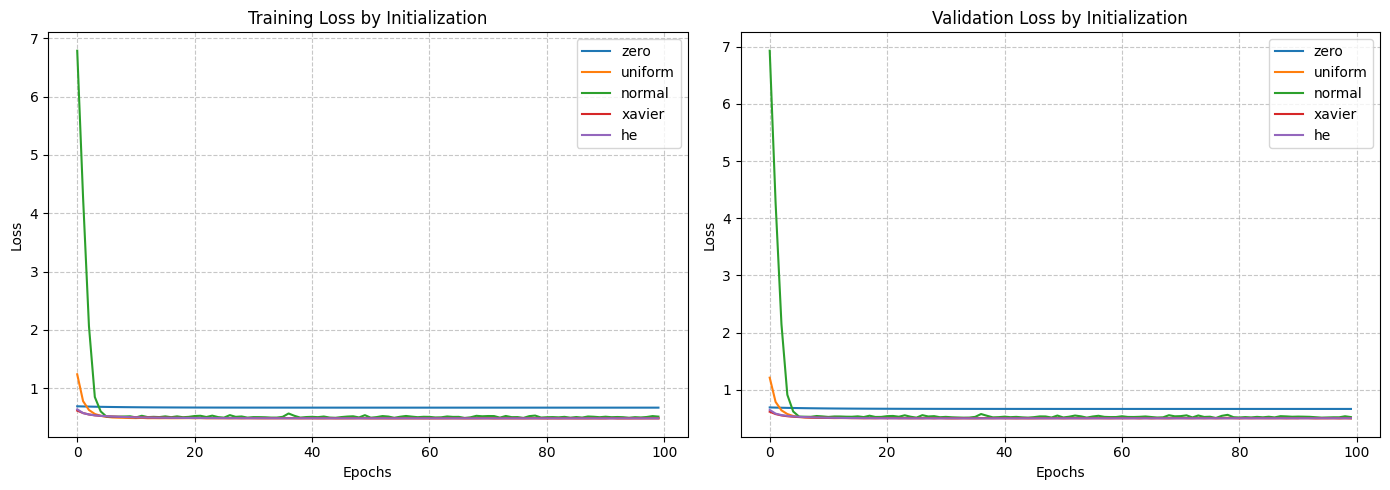


--- Displaying Distributions (Hidden Layers 0 and 1 only) ---

Distributions for Init = zero:


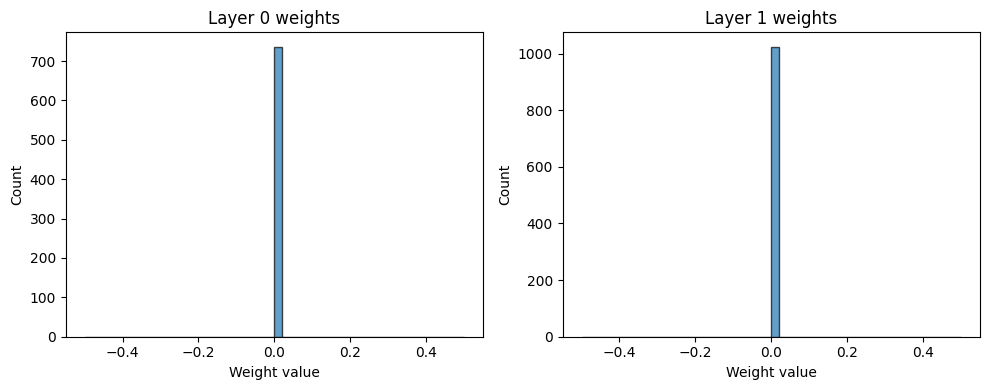

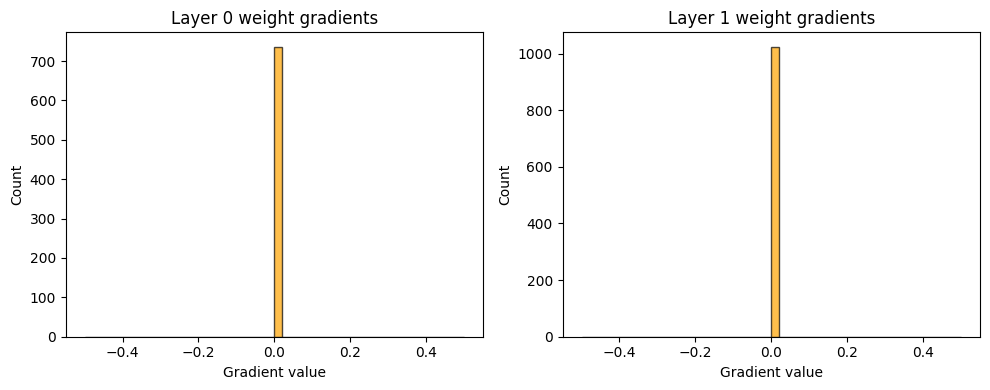


Distributions for Init = uniform:


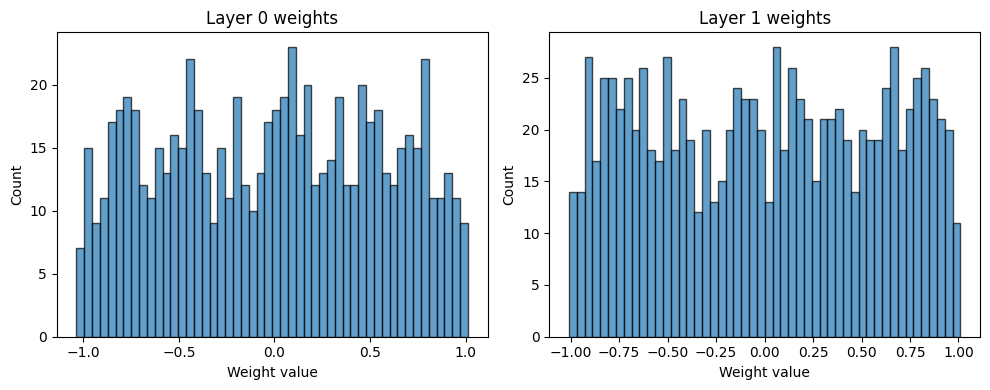

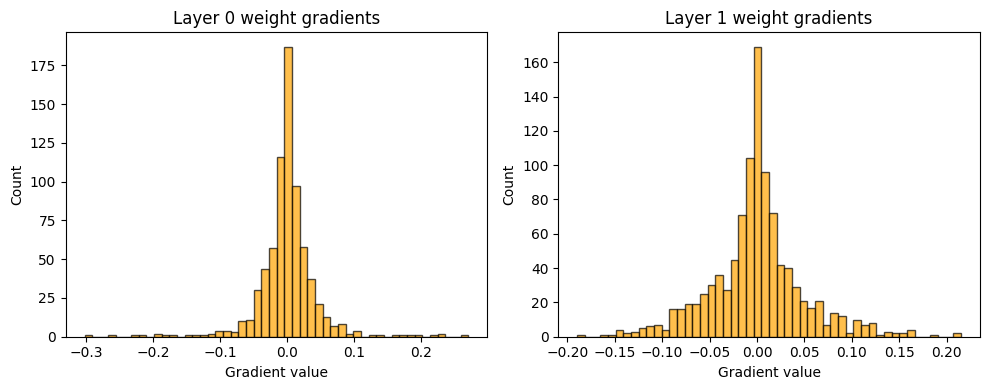


Distributions for Init = normal:


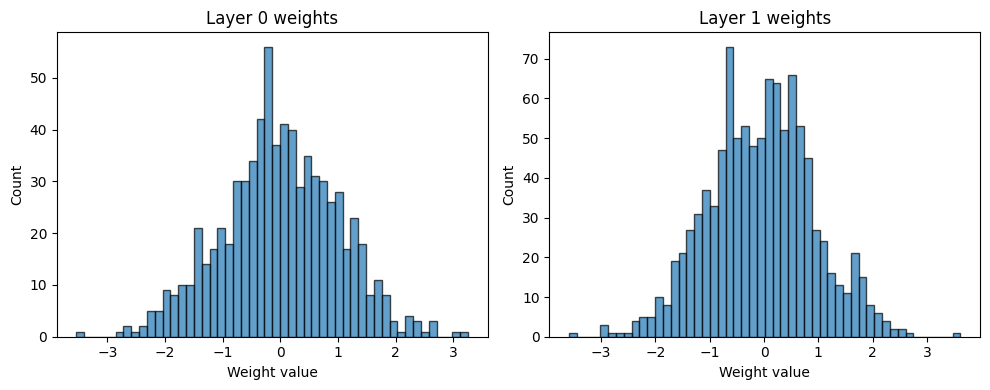

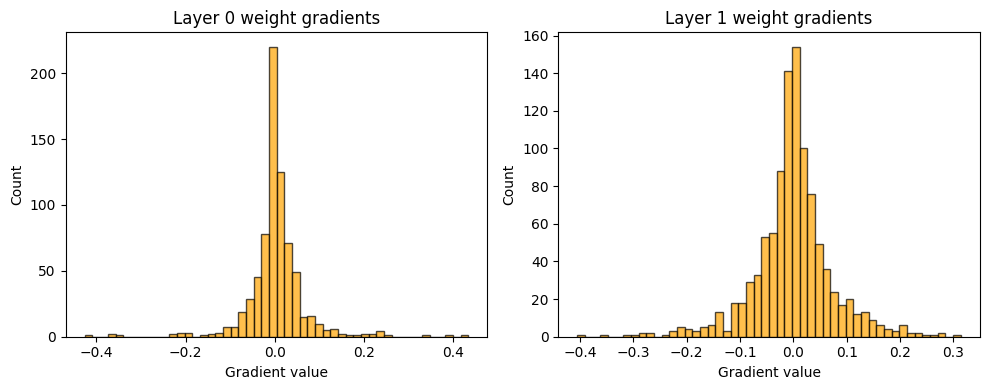


Distributions for Init = xavier:


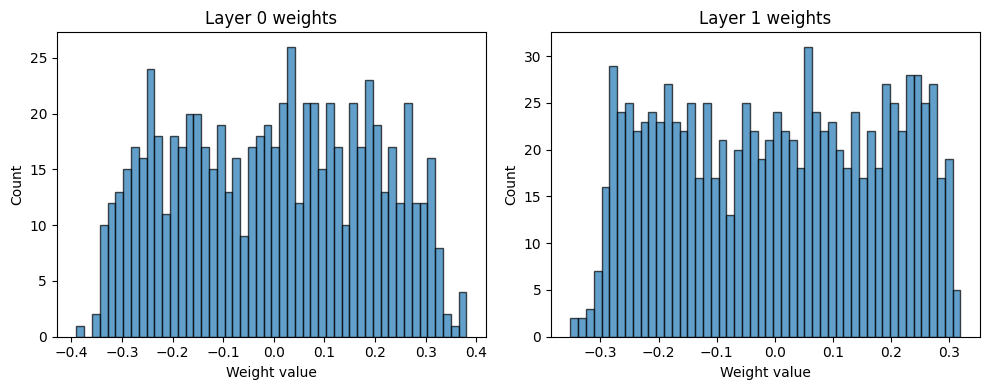

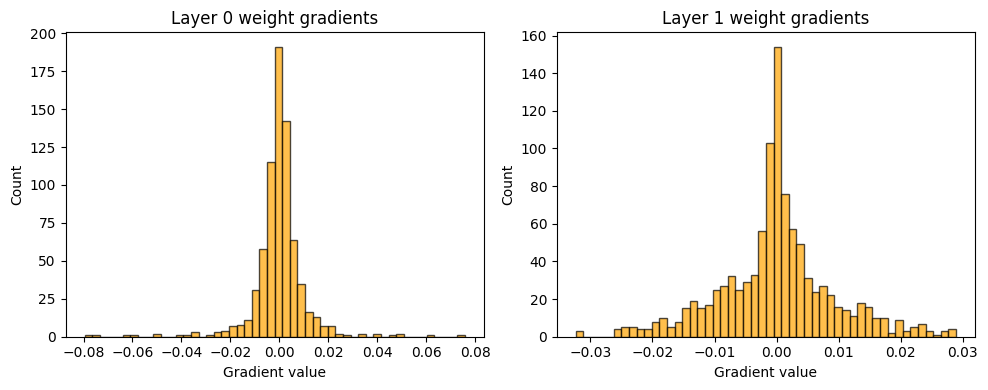


Distributions for Init = he:


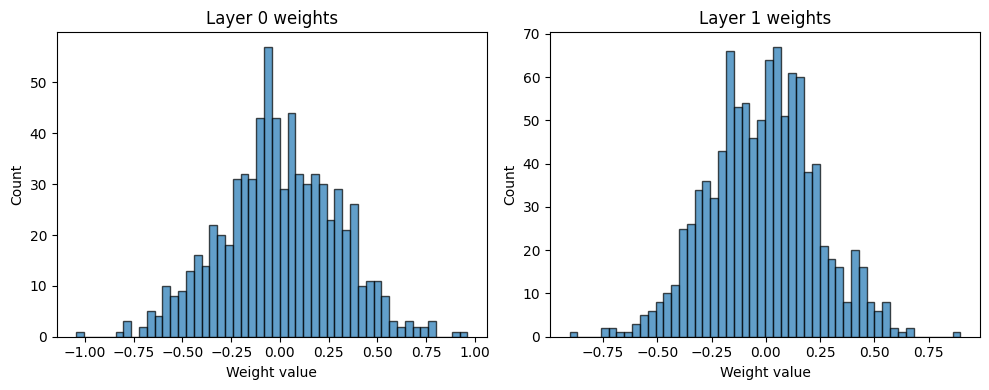

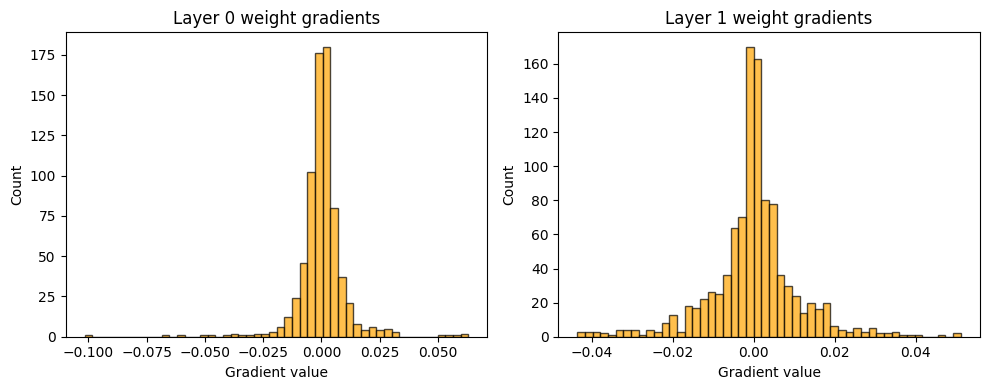

In [11]:
# =====================================================================
# --- EXPERIMENT 4: EFFECT OF WEIGHT INITIALIZATION ---
# =====================================================================
print("\n" + "="*50)
print("EXPERIMENT 4: WEIGHT INITIALIZATION")
print("="*50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["linear", "linear", "sigmoid"]
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001

# Available initializers: "zero", "uniform", "normal", "xavier", "he"
init_configs = ["zero", "uniform", "normal", "xavier", "he"]
init_histories = {}
init_models = {}

for init_name in init_configs:
    model = ChosenNetwork(
        layer_sizes=BASE_ARCH,
        activations=ACTIVATIONS,
        loss="bce",
        seed=SEED_VALUE,
        initializer=init_name
    )

    history = model.fit(X_train, y_train, val_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)

    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_pred, average='binary')

    print(f"[Init: {init_name:<8}] F1 Score: {f1:.5f}")

    init_histories[init_name] = history
    init_models[init_name] = model

# --- Plotting Training & Val Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for init_name, hist in init_histories.items():
    axes[0].plot(hist['train_loss'], label=f"{init_name}")
    axes[1].plot(hist['val_loss'], label=f"{init_name}")

axes[0].set_title("Training Loss by Initialization")
axes[1].set_title("Validation Loss by Initialization")
for ax in axes:
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Weight and Gradient Distributions ---
# Layer 0: INPUT->32 (hidden), Layer 1: 32->32 (hidden), Layer 2: 32->1 (output — excluded)
print("\n--- Displaying Distributions (Hidden Layers 0 and 1 only) ---")
for init_name, model in init_models.items():
    print(f"\nDistributions for Init = {init_name}:")
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])

### Analisis - Eksperimen 4

#### A. Hasil Prediksi Akhir

**F1 Score per metode inisialisasi (arsitektur [INPUT, 32, 32, 1], aktivasi linear-linear-sigmoid, LR = 0.001):**

| Inisialisasi | F1 Score |
|:------------:|:--------:|
| Zero | 0.76657 |
| **Uniform** | **0.80980** |
| Normal | 0.79862 |
| Xavier | 0.80308 |
| He | 0.80631 |

#### B. Interpretasi Kurva Loss

- **Uniform** mencapai performa validasi terbaik pada run ini.
- **He** dan **Xavier** tetap kompetitif dan stabil, hanya sedikit di bawah Uniform.
- **Zero** paling lemah karena masalah symmetry sehingga pembelajaran terbatas.

#### C. Interpretasi Bobot dan Gradien

- Uniform, Xavier, dan He menghasilkan distribusi bobot-gradien yang mendukung proses belajar.
- Zero menampilkan distribusi bobot sangat terpusat di nol, konsisten dengan hambatan pembelajaran.
- He dan Xavier memberi pola gradien yang relatif stabil, tetapi tidak melampaui Uniform pada metrik akhir.

**Kesimpulan Eksperimen 4:** inisialisasi terbaik pada run ini adalah **Uniform** dengan **F1 = 0.80980**.

## Eksperimen 5 — Regularization



EXPERIMENT 5: REGULARIZATION

Regularization Results:
[none      ] F1=0.80308 | Best Val Loss=0.50041 @ epoch 32
[l1_1e-3   ] F1=0.80386 | Best Val Loss=0.74676 @ epoch 100
[l2_1e-3   ] F1=0.80262 | Best Val Loss=0.55999 @ epoch 100


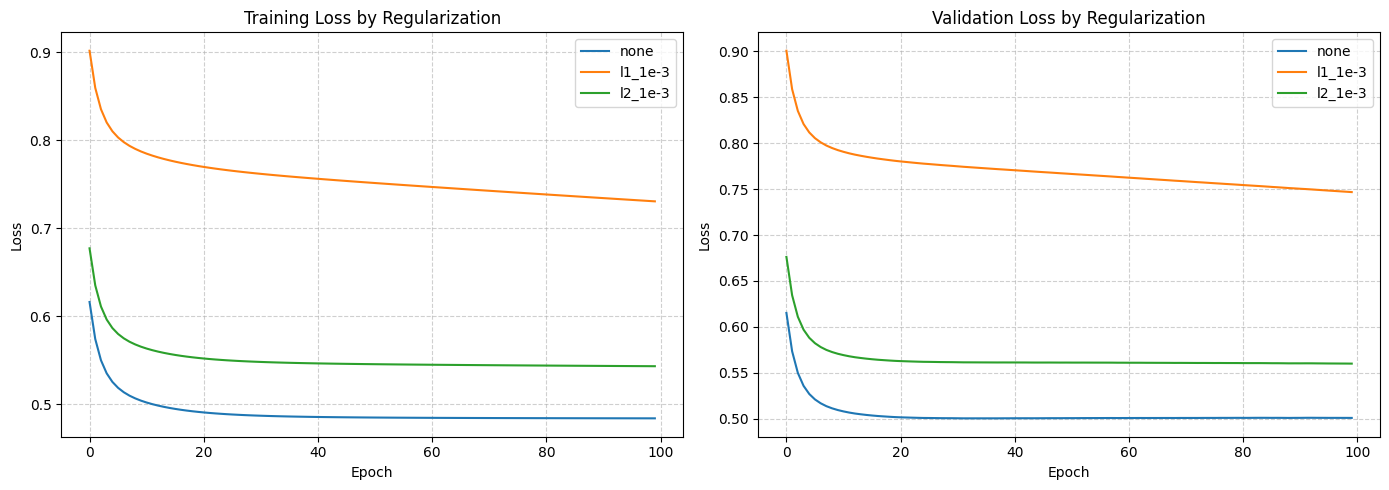


--- Displaying Weight & Gradient Distributions ---

Distributions for scenario = none:


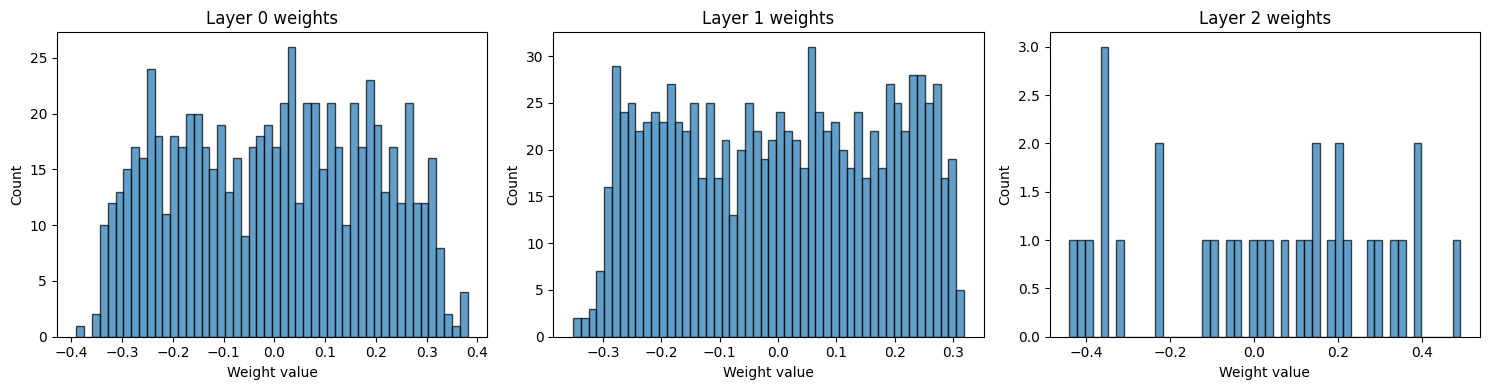

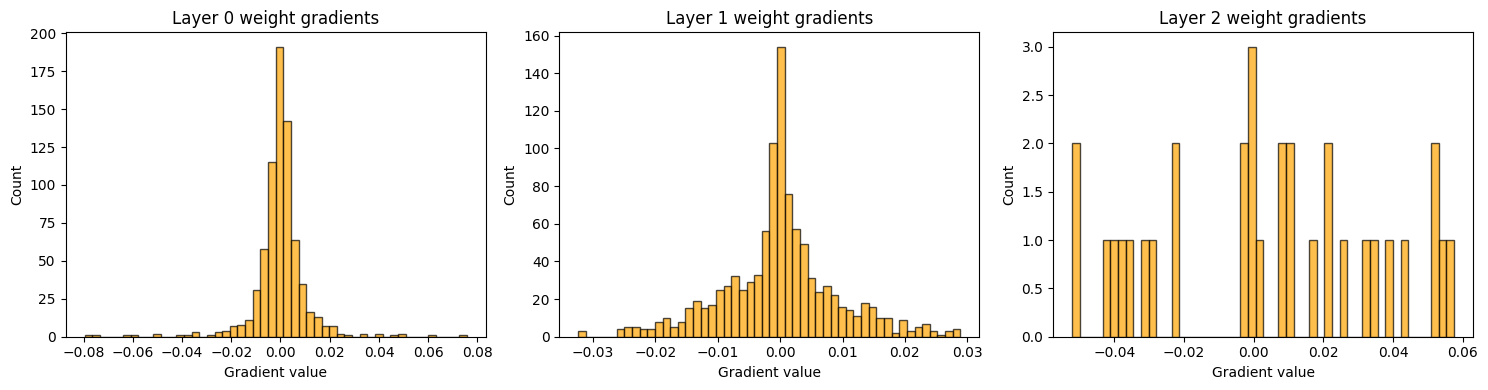


Distributions for scenario = l1_1e-3:


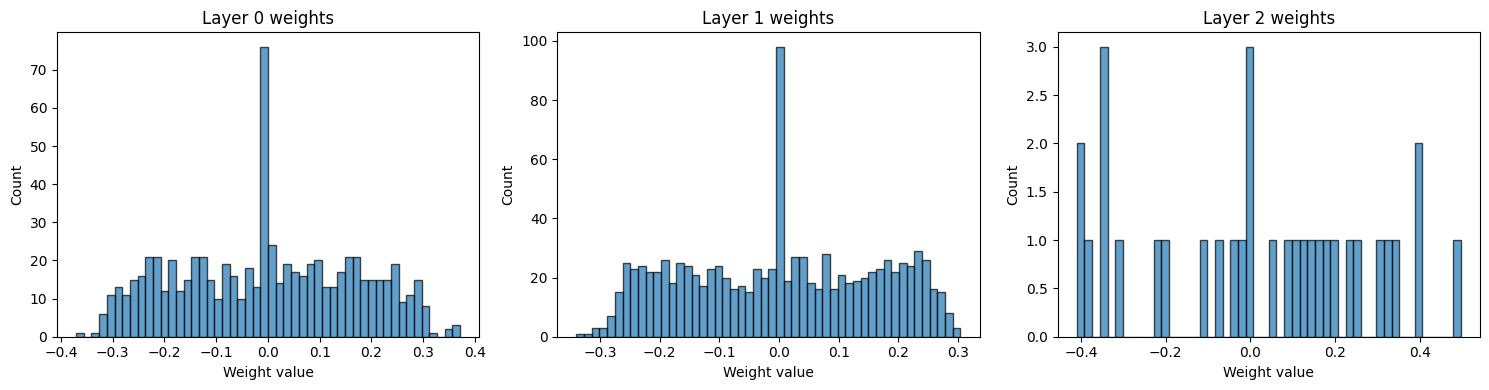

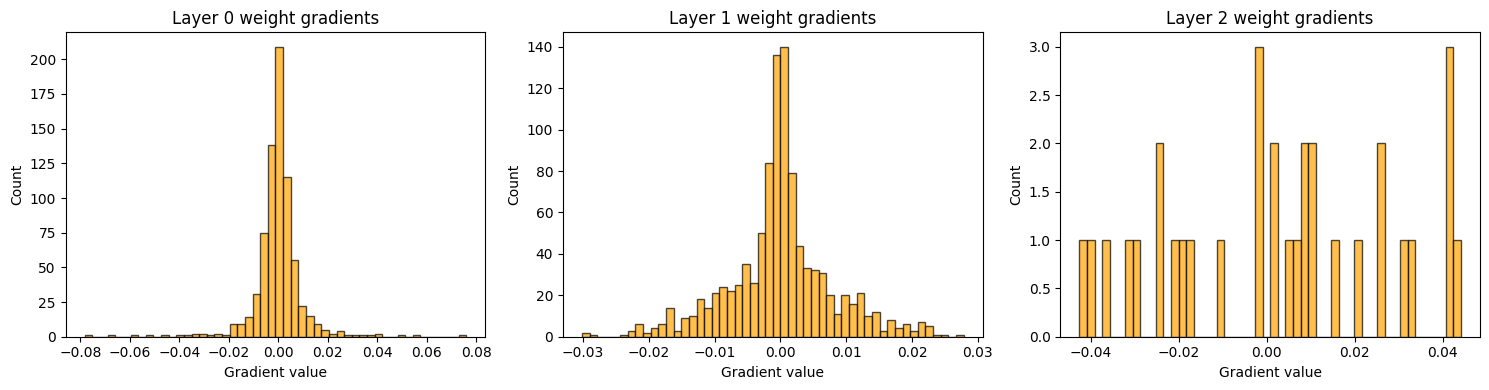


Distributions for scenario = l2_1e-3:


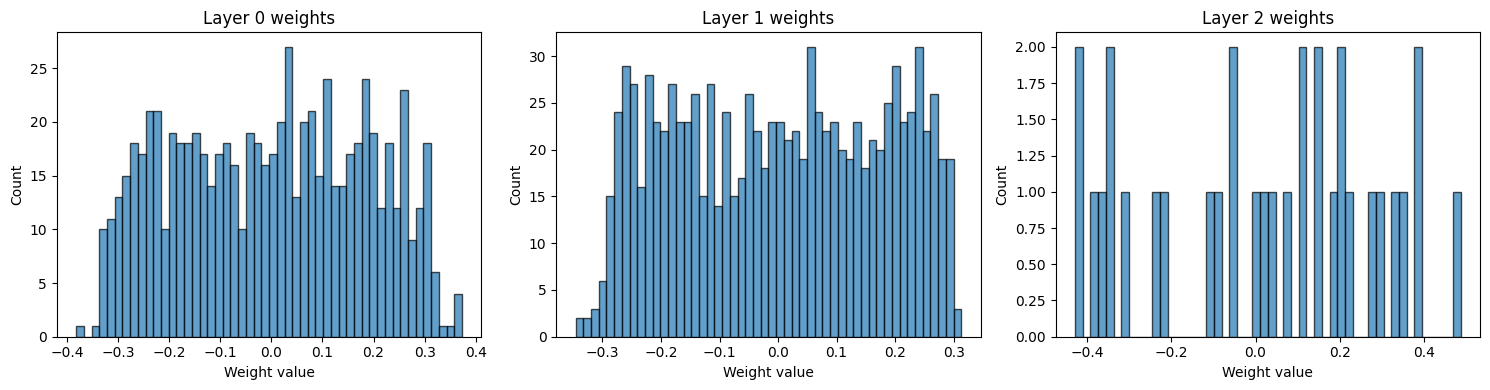

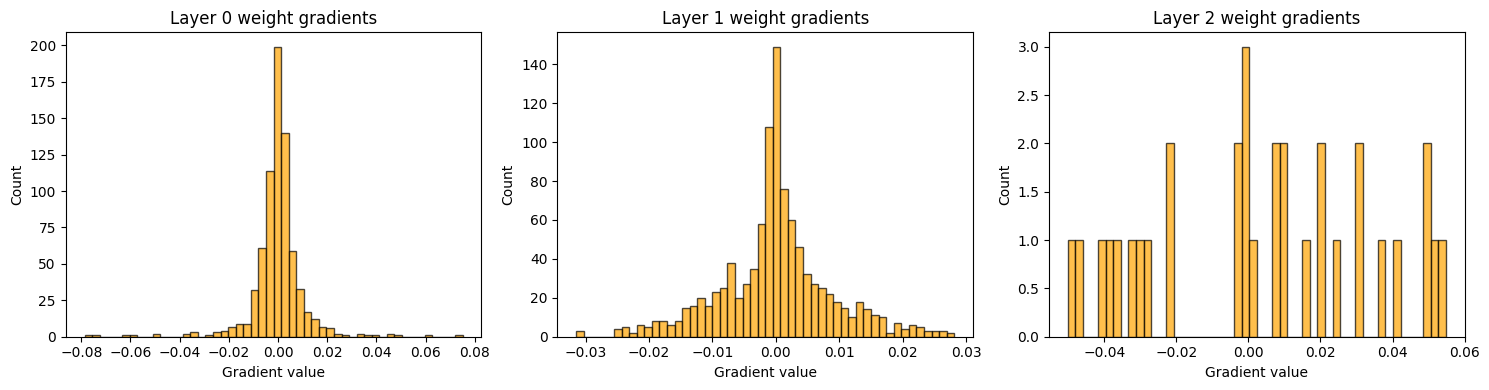

In [12]:
# =====================================================================
# --- EXPERIMENT 5: EFFECT OF REGULARIZATION ON MODEL GENERALIZATION ---
# =====================================================================
print("\n" + "=" * 50)
print("EXPERIMENT 5: REGULARIZATION")
print("=" * 50)

INPUT_DIM = X_train.shape[1]
BASE_ARCH = [INPUT_DIM, 32, 32, 1]
ACTIVATIONS = ["linear", "linear", "sigmoid"]
EPOCHS, BATCH_SIZE, LR = 100, 32, 0.001

# --- Regularization Scenarios ---
reg_scenarios = {
    "none": {"regularization": None, "reg_lambda": 0.0},
    "l1_1e-3": {"regularization": "l1", "reg_lambda": 1e-3},
    "l2_1e-3": {"regularization": "l2", "reg_lambda": 1e-3},
}

reg_histories, reg_metrics, reg_models = {}, {}, {}

for scenario_name, reg_cfg in reg_scenarios.items():
    model = ChosenNetwork(
        layer_sizes=BASE_ARCH,
        activations=ACTIVATIONS,
        loss="bce",
        seed=SEED_VALUE,
        initializer="xavier",
        regularization=reg_cfg["regularization"],
        reg_lambda=reg_cfg["reg_lambda"],
    )
    history = model.fit(X_train, y_train, val_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, verbose=0)
    
    y_pred = (model.predict(X_val) > 0.5).astype(int)
    f1 = f1_score(y_val.ravel(), y_pred.ravel(), average="binary")
    
    reg_histories[scenario_name] = history
    reg_models[scenario_name] = model
    reg_metrics[scenario_name] = {
        "f1": float(f1),
        "best_val_loss": float(np.min(history["val_loss"])),
        "best_epoch": int(np.argmin(history["val_loss"])) + 1,
    }

# --- Print Summary Table ---
print("\nRegularization Results:")
for name, m in reg_metrics.items():
    print(f"[{name:<10}] F1={m['f1']:.5f} | Best Val Loss={m['best_val_loss']:.5f} @ epoch {m['best_epoch']}")

# --- Plot Training & Validation Loss Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in reg_histories.items():
    axes[0].plot(hist["train_loss"], label=name)
    axes[1].plot(hist["val_loss"], label=name)
axes[0].set_title("Training Loss by Regularization")
axes[1].set_title("Validation Loss by Regularization")
for ax in axes:
    ax.set_xlabel("Epoch"), ax.set_ylabel("Loss"), ax.legend(), ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot Weight & Gradient Distributions ---
print("\n--- Displaying Weight & Gradient Distributions ---")
layers_to_plot = list(range(len(BASE_ARCH) - 1))
for name, model in reg_models.items():
    print(f"\nDistributions for scenario = {name}:")
    model.plot_weight_distribution(layers=layers_to_plot)
    model.plot_gradient_distribution(layers=layers_to_plot)

### Analisis - Eksperimen 5

#### A. Hasil Prediksi Akhir

**F1 Score per konfigurasi regularisasi (arsitektur [INPUT, 32, 32, 1], LR = 0.001, lambda = 0.001):**

| Regularisasi | F1 Score |
|:------------:|:--------:|
| None | 0.80308 |
| **L1** | **0.80386** |
| L2 | 0.80262 |

#### B. Interpretasi Kurva Loss

- Pada run ini, **None** memiliki nilai validation loss terendah (Best Val Loss = 0.50041 @ epoch 32).
- **L1** dan **L2** menghasilkan validation loss lebih tinggi karena objective loss memasukkan penalti regularisasi.
- Dari sisi prediksi akhir (F1), **L1** unggul tipis dibanding skenario lain.

#### C. Interpretasi Bobot dan Gradien

- **None:** bobot berkembang tanpa penalti sehingga fleksibilitas model tinggi.
- **L1:** mendorong sparsitas (lebih banyak bobot mendekati nol), dan memberi F1 terbaik pada run ini.
- **L2:** mendorong penyusutan bobot secara halus (weight decay) dengan performa F1 yang sangat dekat.

**Kesimpulan Eksperimen 5:** jika acuan utama adalah metrik prediksi (F1), konfigurasi terbaik pada run ini adalah **L1** dengan **F1 = 0.80386**.

## Eksperimen 6 — Perbandingan dengan Sklearn MLPClassifier


--- Training Sklearn MLPClassifier (Uniform Activation) ---
  Sklearn activation: 'identity'
  Mapped to ours   : 'linear'


/Users/yonatanedwardnjoto/Documents/kuliah/ML-FFNN/src/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Training ChosenNetwork (Uniform Activation: 'linear') ---

Best config summary:
  Architecture     : [23, 128, 32, 128, 1]
  Hidden Activation: identity (ours: linear)
  Learning rate    : 0.001
  Regulariz.       : None (to match Sklearn)

  MODEL COMPARISON (1:1 PARAMS)
  Sklearn  MLPClassifier F1: 0.8014
  ChosenNetwork          F1: 0.8015


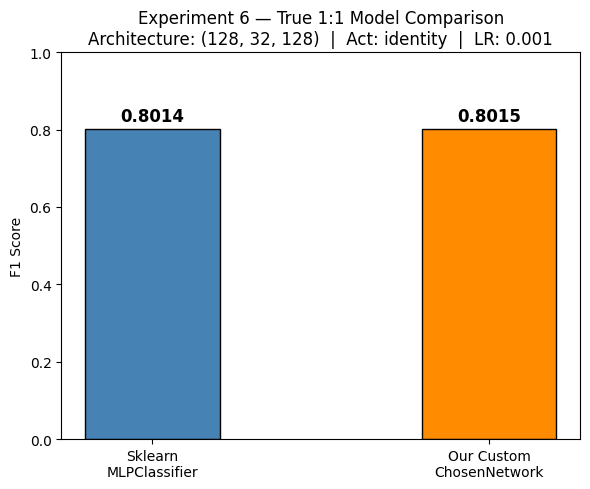

In [13]:
# --- 1. MANUAL CONFIGURATION ---
EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Architecture
INPUT_DIM = X_train.shape[1]
HIDDEN_LAYERS = (128, 32, 128)                 # For sklearn (hidden only)
LAYER_SIZES = [INPUT_DIM, 128, 32, 128, 1]     # For ChosenNetwork (input + hidden + output)

# Activations (uniform for hidden layers)
SKLEARN_ACT = "identity"  # sklearn activation choices: identity, logistic, tanh, relu
SKLEARN_ACT = SKLEARN_ACT.lower()

SKLEARN_TO_OURS_ACTIVATION = {
    "identity": "linear",
    "logistic": "sigmoid",
    "tanh": "tanh",
    "relu": "relu",
}

if SKLEARN_ACT not in SKLEARN_TO_OURS_ACTIVATION:
    raise ValueError(
        f"Unsupported sklearn activation '{SKLEARN_ACT}'. "
        f"Supported: {list(SKLEARN_TO_OURS_ACTIVATION.keys())}"
    )

UNIFORM_ACT_OURS = SKLEARN_TO_OURS_ACTIVATION[SKLEARN_ACT]

print("\n--- Training Sklearn MLPClassifier (Uniform Activation) ---")
print(f"  Sklearn activation: '{SKLEARN_ACT}'")
print(f"  Mapped to ours   : '{UNIFORM_ACT_OURS}'")

# --- 2. TRAIN SKLEARN (Uniform Hidden Activations) ---
np.random.seed(SEED_VALUE)
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=HIDDEN_LAYERS,
    activation=SKLEARN_ACT,
    solver='sgd',
    batch_size=BATCH_SIZE,
    learning_rate_init=LEARNING_RATE,
    learning_rate='constant',       # Ensure LR doesn't decay
    max_iter=EPOCHS,
    alpha=0.0,                      # Turn off sklearn's default L2
    momentum=0.0,                   # Turn off default momentum for vanilla SGD
    nesterovs_momentum=False,
    tol=0.0,                        # Force it to run all epochs
    n_iter_no_change=EPOCHS,
    shuffle=True,
    random_state=SEED_VALUE
)

sklearn_mlp.fit(X_train, y_train.ravel())
y_pred_sklearn = sklearn_mlp.predict(X_val)
f1_sklearn = f1_score(y_val, y_pred_sklearn, average='binary')

# --- 3. TRAIN CHOSEN NETWORK (Uniform Hidden Activations) ---
print(f"\n--- Training ChosenNetwork (Uniform Activation: '{UNIFORM_ACT_OURS}') ---")
uniform_acts_list = [UNIFORM_ACT_OURS] * len(HIDDEN_LAYERS) + ["sigmoid"]

model_uniform = ChosenNetwork(
    layer_sizes=LAYER_SIZES,
    activations=uniform_acts_list,
    loss="bce",
    seed=SEED_VALUE,
    regularization=None,  # Matching sklearn's alpha=0.0
    reg_lambda=0.0
)
model_uniform.fit(
    X_train=X_train, y_train=y_train,
    val_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, verbose=0
)

y_pred_uniform = (model_uniform.predict(X_val) > 0.5).astype(int)
f1_uniform = f1_score(y_val, y_pred_uniform, average='binary')

# --- 4. RESULTS & VISUALIZATION ---
print(f"\nBest config summary:")
print(f"  Architecture     : {LAYER_SIZES}")
print(f"  Hidden Activation: {SKLEARN_ACT} (ours: {UNIFORM_ACT_OURS})")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Regulariz.       : None (to match Sklearn)")

print(f"\n{'='*60}")
print(f"  MODEL COMPARISON (1:1 PARAMS)")
print(f"{'='*60}")
print(f"  Sklearn  MLPClassifier F1: {f1_sklearn:.4f}")
print(f"  ChosenNetwork          F1: {f1_uniform:.4f}")
print(f"{'='*60}")

# Bar chart comparison
labels = ["Sklearn\nMLPClassifier", "Our Custom\nChosenNetwork"]
scores = [f1_sklearn, f1_uniform]
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, scores, color=colors, width=0.4, edgecolor='black')
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score")
ax.set_title(f"Experiment 6 — True 1:1 Model Comparison\nArchitecture: {HIDDEN_LAYERS}  |  Act: {SKLEARN_ACT}  |  LR: {LEARNING_RATE}")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Analisis - Eksperimen 6

#### A. Hasil Prediksi Akhir

**Perbandingan F1 Score (arsitektur [INPUT, 128, 32, 128, 1], aktivasi Linear uniform, LR = 0.001):**

| Model | F1 Score |
|:-----:|:--------:|
| Sklearn MLPClassifier | 0.8014 |
| **FFNN Buatan Sendiri** | **0.8015** |

#### B. Interpretasi

- Performa kedua model sangat dekat, dengan keunggulan tipis pada model FFNN buatan sendiri.
- Sklearn masih menampilkan **ConvergenceWarning** (maksimum iterasi tercapai), sehingga hasilnya masih bisa berubah jika iterasi ditambah.
- Hasil ini mendukung bahwa implementasi FFNN buatan sendiri sudah sebanding dengan baseline pustaka populer.

**Kesimpulan Eksperimen 6:** pada konfigurasi ini, FFNN buatan sendiri unggul tipis (**+0.0001 F1**) terhadap sklearn.

## 5. Rangkuman Akhir

| Eksperimen | Aspek yang Diuji | Pilihan Terbaik | F1 Score |
|:----------:|:----------------:|:---------------:|:--------:|
| Exp 1 | Depth dan Width | Width 64 / Depth 1 | 0.80417 / 0.80385 |
| Exp 2 | Fungsi Aktivasi | Sigmoid | 0.80386 |
| Exp 3 | Learning Rate | LR = 0.01 | 0.8032 |
| Exp 3B | Optimizer + LR (linear-linear-sigmoid) | Adam + LR=0.0001 (F1), Adam + LR=0.001 (speed) | 0.8034 |
| Exp 4 | Inisialisasi Bobot | Uniform | 0.80980 |
| Exp 5 | Regularisasi | L1 (berdasarkan F1) | 0.80386 |
| Exp 6 | Perbandingan dengan sklearn | FFNN Buatan Sendiri | 0.8015 vs 0.8014 |

**Kesimpulan umum:**
- F1 tertinggi keseluruhan pada notebook ini muncul di **Eksperimen 4 (Uniform initialization)**: **0.80980**.
- Pada beberapa eksperimen (aktivasi, learning rate, regularisasi), selisih performa akhir antar konfigurasi relatif kecil.
- Pada setup aktivasi linear-linear-sigmoid (Exp 3B), **Adam** tetap lebih unggul daripada SGD dari sisi robustnes LR dan kecepatan konvergensi.
- Implementasi FFNN buatan sendiri tetap kompetitif terhadap sklearn pada konfigurasi yang disetarakan.